# XGBoost Prediction with SHAP Analysis and Binning

This notebook performs prediction using XGBoost with the following features:
- **Binning** for continuous variables
- **GridSearchCV** with cross-validation
- **Variance analysis** between folds
- **SHAP** analysis for model interpretability

## 1. Environment Setup

In [1]:
%pip install xgboost shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import shap

# Ensure plots are displayed inline
%matplotlib inline

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Loading

In [3]:
# Setup Kaggle API key if not already present
if not os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    import shutil
    if os.path.exists('kaggle.json'):
        shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/'))
        os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# Download dataset if not present
if not os.path.exists('data/heloc_dataset_v1.csv'):
    !mkdir -p data
    !kaggle datasets download -d averkiyoliabev/home-equity-line-of-creditheloc
    !unzip -o home-equity-line-of-creditheloc.zip -d data/
    # Rename if necessary
    if os.path.exists('data/heloc_dataset_v1 (1).csv'):
        os.rename('data/heloc_dataset_v1 (1).csv', 'data/heloc_dataset_v1.csv')

In [4]:
df = pd.read_csv("data/heloc_dataset_v1.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10459, 24)


,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,...,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,...,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,...,25,0,1,1,51,89,3,1,0,80


## 3. Exploratory Data Analysis

In [5]:
# Check for missing values (special codes: -9, -8, -7)
special_codes = [-9, -8, -7]
missing_counts = {}
for col in df.columns[1:]:
    missing_counts[col] = df[col].isin(special_codes).sum()

missing_df = pd.DataFrame.from_dict(missing_counts, orient='index', columns=['Missing Count'])
missing_df['Missing %'] = (missing_df['Missing Count'] / len(df)) * 100
missing_df = missing_df.sort_values('Missing %', ascending=False)
print("\nTop 10 features with missing values:")
print(missing_df.head(10))


Top 10 features with missing values:
                                    Missing Count  Missing %
MSinceMostRecentDelq                         5428  51.897887
NetFractionInstallBurden                     4007  38.311502
MSinceMostRecentInqexcl7days                 2919  27.908978
NumInstallTradesWBalance                     1449  13.854097
NumBank2NatlTradesWHighUtilization           1171  11.196099
MSinceOldestTradeOpen                         827   7.907066
NetFractionRevolvingBurden                    774   7.400325
NumRevolvingTradesWBalance                    744   7.113491
PercentTradesWBalance                         606   5.794053
ExternalRiskEstimate                          598   5.717564



Target distribution:
RiskPerformance
Bad     5459
Good    5000
Name: count, dtype: int64

Target distribution (normalized):
RiskPerformance
Bad     0.521943
Good    0.478057
Name: proportion, dtype: float64


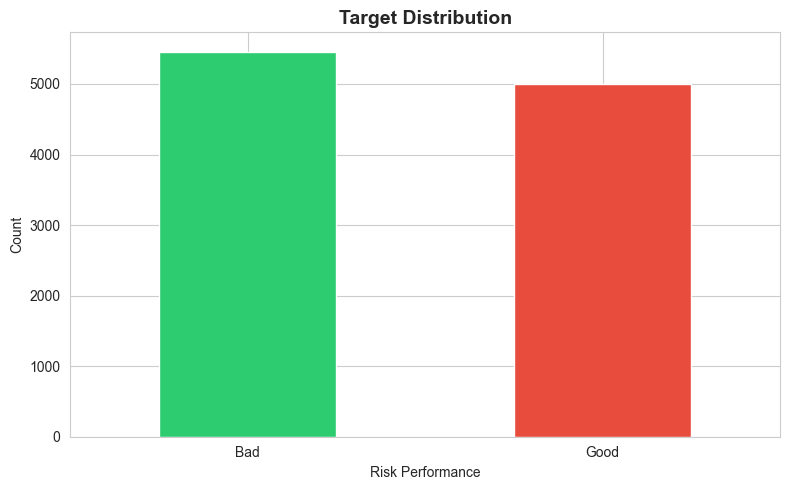

In [6]:
# Target distribution
print("\nTarget distribution:")
print(df['RiskPerformance'].value_counts())
print("\nTarget distribution (normalized):")
print(df['RiskPerformance'].value_counts(normalize=True))

# Visualize target distribution
plt.figure(figsize=(8, 5))
df['RiskPerformance'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Target Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Risk Performance')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Preprocessing and Feature Engineering

In [7]:
# Define variable names (exclude target)
variable_names = list(df.columns[1:])
X = df[variable_names].values

# Encode target: Bad = 1, Good = 0
y = df.RiskPerformance.values
mask = y == "Bad"
y[mask] = 1
y[~mask] = 0
y = y.astype(int)

print(f"Target distribution:\n{pd.Series(y).value_counts(normalize=True)}")

Target distribution:
1    0.521943
0    0.478057
Name: proportion, dtype: float64


In [8]:
# Handle special codes (-9, -8, -7) as missing values
X = np.where(np.isin(X, special_codes), np.nan, X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set target distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"\nTest set target distribution:\n{pd.Series(y_test).value_counts(normalize=True)}")

Training set size: (8367, 23)
Test set size: (2092, 23)

Training set target distribution:
1    0.521931
0    0.478069
Name: proportion, dtype: float64

Test set target distribution:
1    0.521989
0    0.478011
Name: proportion, dtype: float64


### 4.1 Imputation

In [9]:
# Impute missing values using KNN Imputer
imputer = KNNImputer(n_neighbors=5, weights='distance')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print(f"Missing values after imputation (train): {np.isnan(X_train_imputed).sum()}")
print(f"Missing values after imputation (test): {np.isnan(X_test_imputed).sum()}")

Missing values after imputation (train): 0
Missing values after imputation (test): 0


### 4.2 Binning Continuous Variables

We'll apply binning to continuous variables to create discrete features. This can help:
- Reduce the impact of outliers
- Capture non-linear relationships
- Improve model interpretability

In [10]:
# Identify continuous variables (those with more than 20 unique values)
continuous_features = []
for i, col in enumerate(variable_names):
    unique_vals = len(np.unique(X_train_imputed[:, i]))
    if unique_vals > 20:
        continuous_features.append(i)

print(f"Number of continuous features identified: {len(continuous_features)}")
print(f"Continuous features: {[variable_names[i] for i in continuous_features]}")

Number of continuous features identified: 18
Continuous features: ['ExternalRiskEstimate', 'MSinceOldestTradeOpen', 'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades', 'PercentTradesNeverDelq', 'MSinceMostRecentDelq', 'NumTotalTrades', 'PercentInstallTrades', 'MSinceMostRecentInqexcl7days', 'NumInqLast6M', 'NumInqLast6Mexcl7days', 'NetFractionRevolvingBurden', 'NetFractionInstallBurden', 'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance', 'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance']


In [11]:
# Apply binning to continuous features
# We'll use quantile-based binning to ensure equal-sized bins
n_bins = 5
binning_strategy = 'quantile'  # Options: 'uniform', 'quantile', 'kmeans'

# Create a copy of the data for binning
X_train_binned = X_train_imputed.copy()
X_test_binned = X_test_imputed.copy()

# Store binners for each continuous feature
binners = {}

for feat_idx in continuous_features:
    binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=binning_strategy)
    
    # Fit on training data and transform both train and test
    X_train_binned[:, feat_idx] = binner.fit_transform(X_train_imputed[:, feat_idx].reshape(-1, 1)).ravel()
    X_test_binned[:, feat_idx] = binner.transform(X_test_imputed[:, feat_idx].reshape(-1, 1)).ravel()
    
    binners[feat_idx] = binner

print(f"\nBinning completed for {len(continuous_features)} features")
print(f"Binning strategy: {binning_strategy}")
print(f"Number of bins: {n_bins}")


Binning completed for 18 features
Binning strategy: quantile
Number of bins: 5


c:\Users\joshu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\joshu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\joshu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization

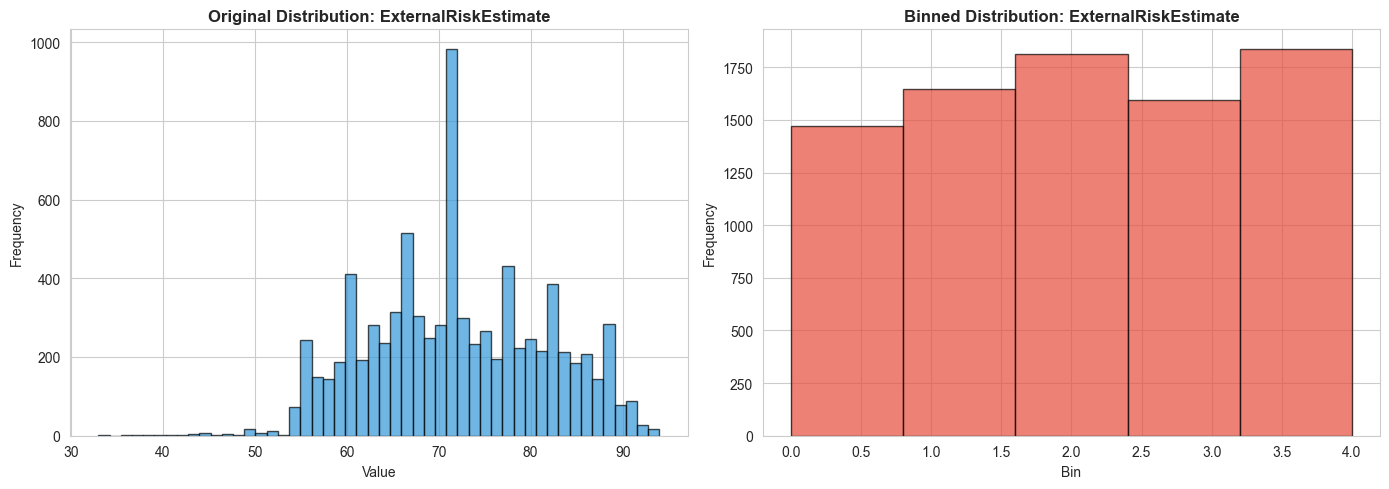

In [12]:
# Visualize binning for a sample feature
if len(continuous_features) > 0:
    sample_feat_idx = continuous_features[0]
    sample_feat_name = variable_names[sample_feat_idx]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Original distribution
    axes[0].hist(X_train_imputed[:, sample_feat_idx], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
    axes[0].set_title(f'Original Distribution: {sample_feat_name}', fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    
    # Binned distribution
    axes[1].hist(X_train_binned[:, sample_feat_idx], bins=n_bins, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[1].set_title(f'Binned Distribution: {sample_feat_name}', fontweight='bold')
    axes[1].set_xlabel('Bin')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

### 4.3 Scaling

Although XGBoost is tree-based and doesn't require scaling, we'll scale the features for consistency and to help with SHAP analysis.

In [13]:
# Scale the binned features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_binned)
X_test_scaled = scaler.transform(X_test_binned)

print(f"Scaling completed")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Scaling completed
Training set shape: (8367, 23)
Test set shape: (2092, 23)


## 5. Model Training with GridSearchCV

In [14]:
# Define XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1, 1.1]  # Adjust for class imbalance
}

print("Parameter grid defined:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")
print(f"\nTotal combinations: {np.prod([len(v) for v in param_grid.values()])}")

Parameter grid defined:
  n_estimators: [100, 200, 300]
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.1, 0.3]
  subsample: [0.7, 0.8, 1.0]
  colsample_bytree: [0.7, 0.8, 1.0]
  gamma: [0, 0.1, 0.2]
  min_child_weight: [1, 3, 5]
  scale_pos_weight: [1, 1.1]

Total combinations: 4374


In [15]:
# For computational efficiency, we'll use a smaller parameter grid
# You can expand this for more thorough search
param_grid_reduced = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1],
    'min_child_weight': [1, 3],
    'scale_pos_weight': [1, 1.1]
}

print("Reduced parameter grid:")
for param, values in param_grid_reduced.items():
    print(f"  {param}: {values}")
print(f"\nTotal combinations: {np.prod([len(v) for v in param_grid_reduced.values()])}")

Reduced parameter grid:
  n_estimators: [100, 200]
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.1]
  subsample: [0.8, 1.0]
  colsample_bytree: [0.8, 1.0]
  gamma: [0, 0.1]
  min_child_weight: [1, 3]
  scale_pos_weight: [1, 1.1]

Total combinations: 384


In [16]:
# Setup cross-validation
cv_folds = 5
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_reduced,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print(f"\nStarting GridSearchCV with {cv_folds}-fold cross-validation...")
print(f"Scoring metric: ROC AUC")
print(f"This may take several minutes...\n")


Starting GridSearchCV with 5-fold cross-validation...
Scoring metric: ROC AUC
This may take several minutes...



In [17]:
# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*60)
print("GridSearchCV completed!")
print("="*60)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best ROC AUC (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 384 candidates, totalling 1920 fits

GridSearchCV completed!

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 1.0}
Best ROC AUC (CV): 0.7881


c:\Users\joshu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:52:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 6. Cross-Validation Variance Analysis

In [18]:
# Extract CV results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Get the best model's CV scores across folds
best_idx = grid_search.best_index_
fold_scores = []
for fold in range(cv_folds):
    fold_scores.append(cv_results.loc[best_idx, f'split{fold}_test_score'])

print("\n" + "="*60)
print("Cross-Validation Variance Analysis")
print("="*60)
print(f"\nScores across {cv_folds} folds:")
for i, score in enumerate(fold_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean Score: {np.mean(fold_scores):.4f}")
print(f"Std Deviation: {np.std(fold_scores):.4f}")
print(f"Variance: {np.var(fold_scores):.6f}")
print(f"Min Score: {np.min(fold_scores):.4f}")
print(f"Max Score: {np.max(fold_scores):.4f}")
print(f"Range: {np.max(fold_scores) - np.min(fold_scores):.4f}")
print(f"Coefficient of Variation: {(np.std(fold_scores) / np.mean(fold_scores)) * 100:.2f}%")


Cross-Validation Variance Analysis

Scores across 5 folds:
  Fold 1: 0.7844
  Fold 2: 0.7945
  Fold 3: 0.7748
  Fold 4: 0.7819
  Fold 5: 0.8051

Mean Score: 0.7881
Std Deviation: 0.0106
Variance: 0.000112
Min Score: 0.7748
Max Score: 0.8051
Range: 0.0304
Coefficient of Variation: 1.34%


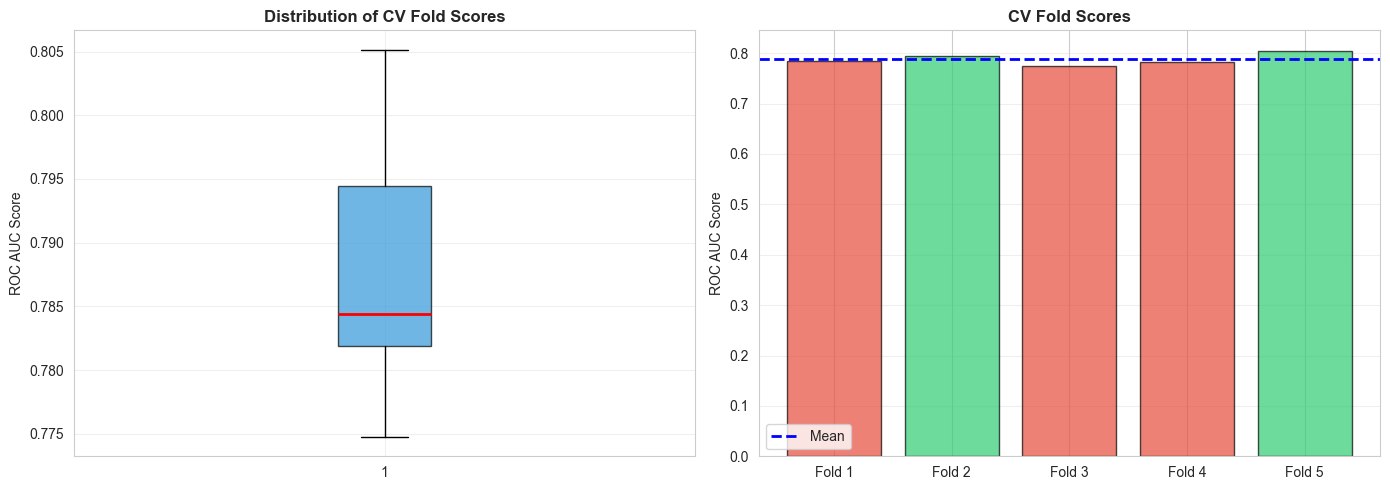

In [19]:
# Visualize fold variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(fold_scores, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_ylabel('ROC AUC Score')
axes[0].set_title('Distribution of CV Fold Scores', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Bar plot
fold_names = [f'Fold {i+1}' for i in range(cv_folds)]
colors = ['#2ecc71' if score >= np.mean(fold_scores) else '#e74c3c' for score in fold_scores]
axes[1].bar(fold_names, fold_scores, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=np.mean(fold_scores), color='blue', linestyle='--', linewidth=2, label='Mean')
axes[1].set_ylabel('ROC AUC Score')
axes[1].set_title('CV Fold Scores', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [20]:
# Analyze variance across all parameter combinations
cv_results['mean_test_score_std'] = cv_results[[f'split{i}_test_score' for i in range(cv_folds)]].std(axis=1)
cv_results['mean_test_score_var'] = cv_results[[f'split{i}_test_score' for i in range(cv_folds)]].var(axis=1)

# Top 10 most stable models (lowest variance)
print("\n" + "="*60)
print("Top 10 Most Stable Models (Lowest Variance)")
print("="*60)
stable_models = cv_results.nsmallest(10, 'mean_test_score_var')[['params', 'mean_test_score', 'mean_test_score_std', 'mean_test_score_var']]
for idx, row in stable_models.iterrows():
    print(f"\nRank {list(stable_models.index).index(idx) + 1}:")
    print(f"  Mean Score: {row['mean_test_score']:.4f}")
    print(f"  Std Dev: {row['mean_test_score_std']:.4f}")
    print(f"  Variance: {row['mean_test_score_var']:.6f}")
    print(f"  Params: {row['params']}")


Top 10 Most Stable Models (Lowest Variance)

Rank 1:
  Mean Score: 0.7756
  Std Dev: 0.0077
  Variance: 0.000059
  Params: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'scale_pos_weight': 1.1, 'subsample': 1.0}

Rank 2:
  Mean Score: 0.7684
  Std Dev: 0.0082
  Variance: 0.000068
  Params: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'scale_pos_weight': 1.1, 'subsample': 0.8}

Rank 3:
  Mean Score: 0.7625
  Std Dev: 0.0084
  Variance: 0.000071
  Params: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}

Rank 4:
  Mean Score: 0.7757
  Std Dev: 0.0088
  Variance: 0.000077
  Params: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'scale_pos_weight': 1.1,

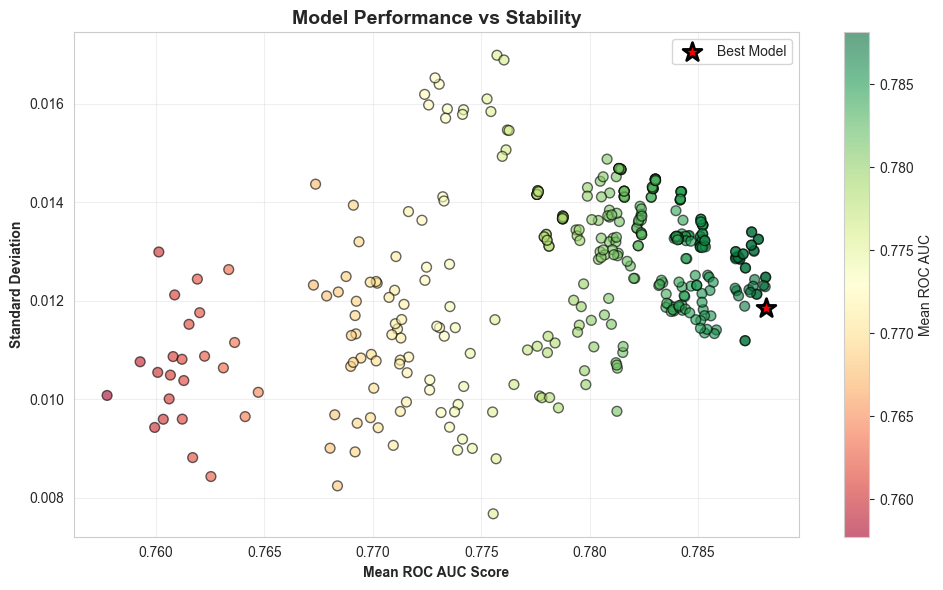

In [21]:
# Visualize mean score vs variance
plt.figure(figsize=(10, 6))
scatter = plt.scatter(cv_results['mean_test_score'], 
                     cv_results['mean_test_score_std'],
                     c=cv_results['mean_test_score'],
                     cmap='RdYlGn',
                     s=50,
                     alpha=0.6,
                     edgecolors='black')

# Highlight best model
plt.scatter(grid_search.best_score_, 
           cv_results.loc[best_idx, 'mean_test_score_std'],
           color='red',
           s=200,
           marker='*',
           edgecolors='black',
           linewidths=2,
           label='Best Model',
           zorder=5)

plt.xlabel('Mean ROC AUC Score', fontweight='bold')
plt.ylabel('Standard Deviation', fontweight='bold')
plt.title('Model Performance vs Stability', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Mean ROC AUC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model Evaluation

In [22]:
# Get best model
best_model = grid_search.best_estimator_

# Predictions on test set
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "="*60)
print("Test Set Performance")
print("="*60)
print(f"\nAccuracy: {test_accuracy:.4f}")
print(f"ROC AUC: {test_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Good', 'Bad']))


Test Set Performance

Accuracy: 0.7161
ROC AUC: 0.7827

Classification Report:
              precision    recall  f1-score   support

        Good       0.72      0.67      0.69      1000
         Bad       0.71      0.76      0.74      1092

    accuracy                           0.72      2092
   macro avg       0.72      0.71      0.71      2092
weighted avg       0.72      0.72      0.72      2092



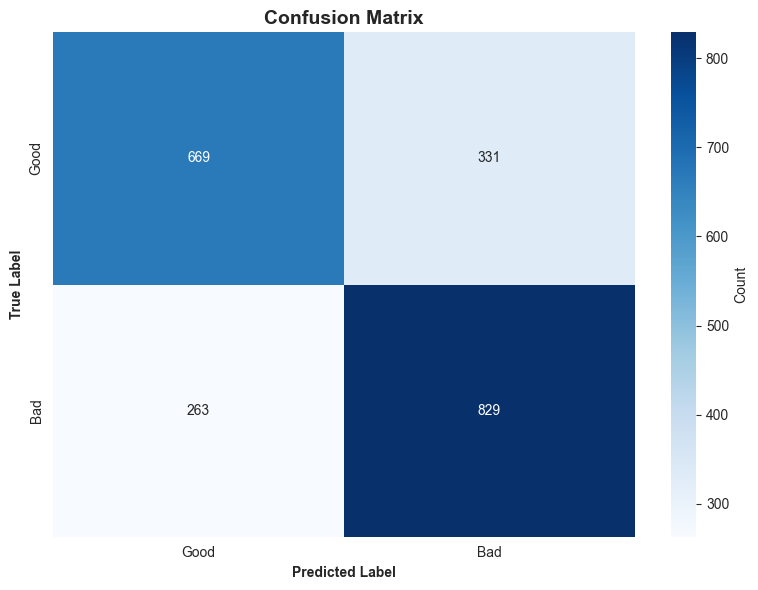

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good', 'Bad'],
            yticklabels=['Good', 'Bad'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.show()

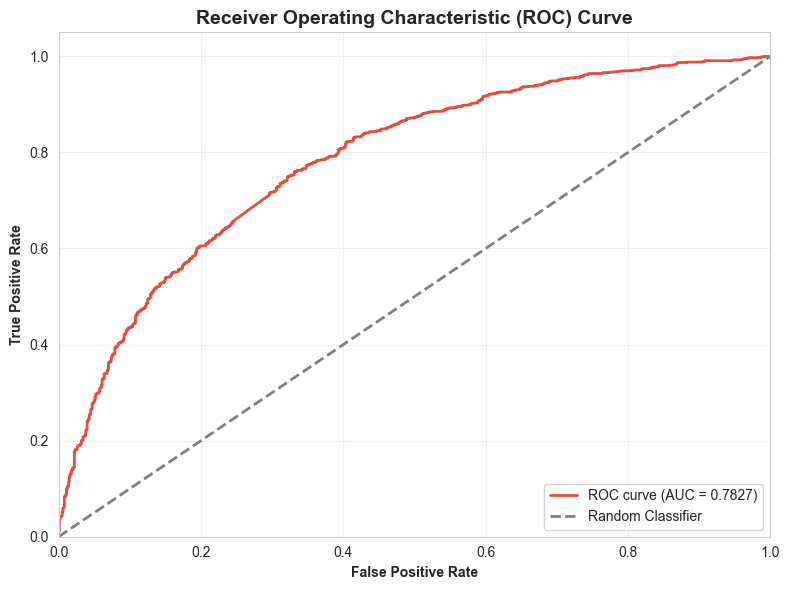

In [24]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Feature Importance (XGBoost Built-in)

In [25]:
# Get feature importance from XGBoost
feature_importance = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': variable_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance_df.head(15))


Top 15 Most Important Features:
                               Feature  Importance
0                 ExternalRiskEstimate    0.378213
7               PercentTradesNeverDelq    0.098122
17          NetFractionRevolvingBurden    0.091253
14        MSinceMostRecentInqexcl7days    0.059705
3                       AverageMInFile    0.051709
22               PercentTradesWBalance    0.050493
4                NumSatisfactoryTrades    0.033412
8                 MSinceMostRecentDelq    0.026542
13                PercentInstallTrades    0.022725
1                MSinceOldestTradeOpen    0.022668
21  NumBank2NatlTradesWHighUtilization    0.022151
11                      NumTotalTrades    0.019233
9             MaxDelq2PublicRecLast12M    0.018040
10                         MaxDelqEver    0.015404
19          NumRevolvingTradesWBalance    0.013153


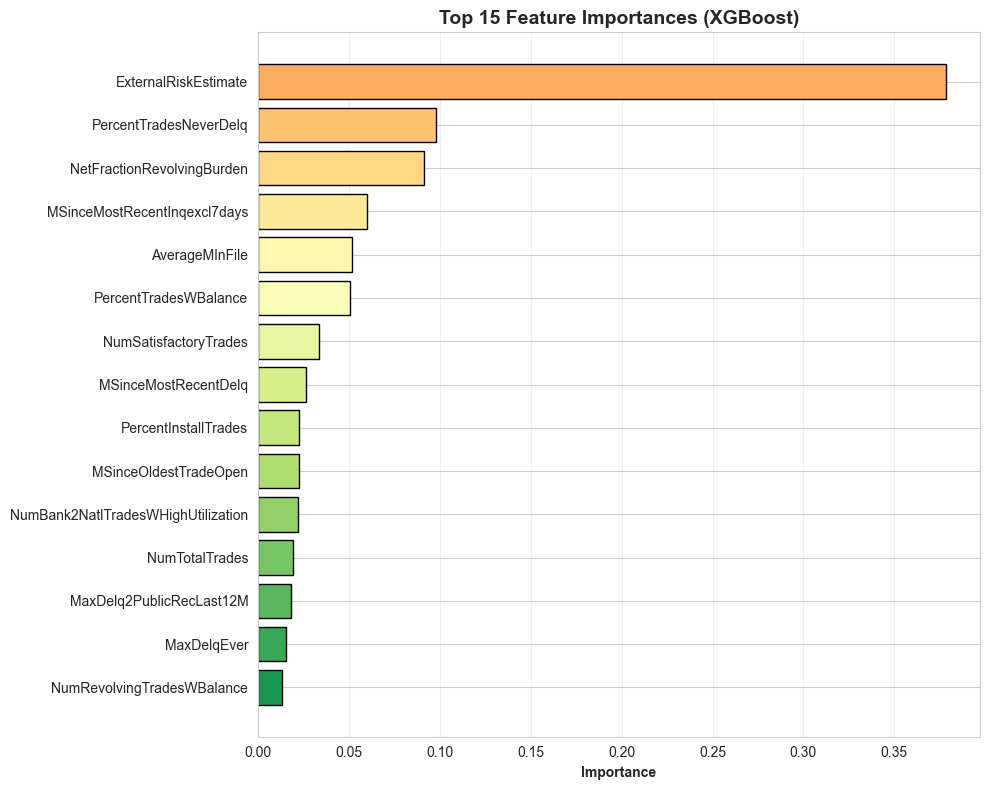

In [26]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
top_n = 15
top_features = feature_importance_df.head(top_n)

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))
plt.barh(range(top_n), top_features['Importance'].values, color=colors, edgecolor='black')
plt.yticks(range(top_n), top_features['Feature'].values)
plt.xlabel('Importance', fontweight='bold')
plt.title(f'Top {top_n} Feature Importances (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 9. SHAP Analysis

SHAP (SHapley Additive exPlanations) provides a unified measure of feature importance and helps explain individual predictions.

In [27]:
# Create SHAP explainer for XGBoost
# For tree-based models, we use TreeExplainer which is much faster
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set
print("Calculating SHAP values for test set...")
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP calculation completed!")

Calculating SHAP values for test set...
SHAP values shape: (2092, 23)
SHAP calculation completed!


### 9.1 SHAP Summary Plot

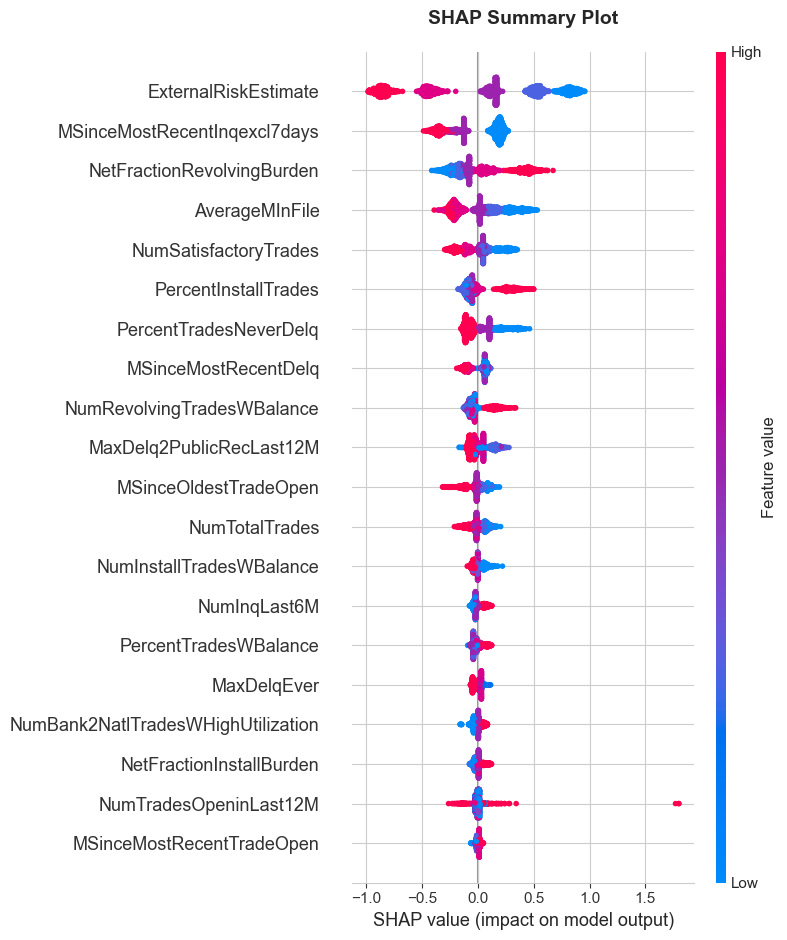

In [28]:
# SHAP Summary Plot (shows feature importance and impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=variable_names, show=False)
plt.title('SHAP Summary Plot', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 9.2 SHAP Bar Plot (Mean Absolute SHAP Values)

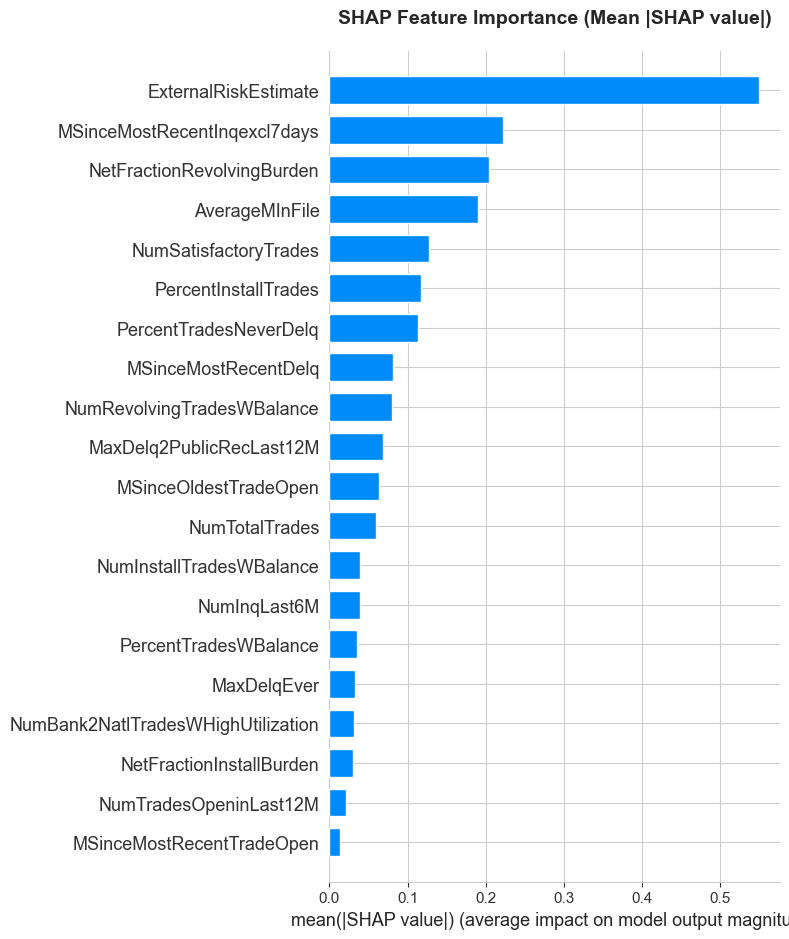

In [29]:
# SHAP Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=variable_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 9.3 SHAP Dependence Plots

In [30]:
# Get top 3 most important features based on mean absolute SHAP values
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
top_feature_indices = np.argsort(mean_abs_shap)[::-1][:3]
top_feature_names = [variable_names[i] for i in top_feature_indices]

print(f"Top 3 features by SHAP importance: {top_feature_names}")

Top 3 features by SHAP importance: ['ExternalRiskEstimate', 'MSinceMostRecentInqexcl7days', 'NetFractionRevolvingBurden']


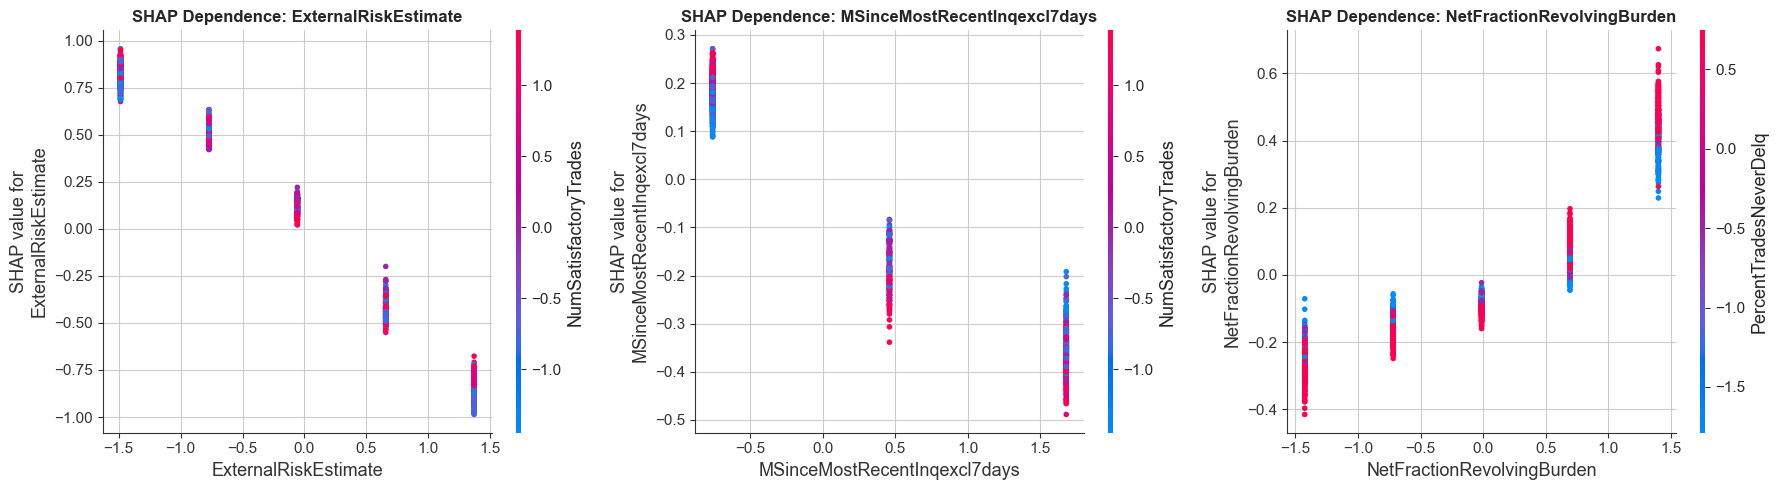

In [31]:
# SHAP Dependence Plots for top 3 features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (feat_idx, feat_name) in enumerate(zip(top_feature_indices, top_feature_names)):
    plt.sca(axes[i])
    shap.dependence_plot(feat_idx, shap_values, X_test_scaled, 
                        feature_names=variable_names, 
                        show=False, ax=axes[i])
    axes[i].set_title(f'SHAP Dependence: {feat_name}', fontweight='bold')

plt.tight_layout()
plt.show()

### 9.4 SHAP Force Plot (Individual Predictions)

In [32]:
# Initialize JavaScript visualization
shap.initjs()

# Select a few interesting predictions to explain
# Let's pick: one correct positive, one correct negative, one false positive, one false negative
correct_positive = np.where((y_test == 1) & (y_pred == 1))[0][0]
correct_negative = np.where((y_test == 0) & (y_pred == 0))[0][0]
false_positive = np.where((y_test == 0) & (y_pred == 1))[0][0] if len(np.where((y_test == 0) & (y_pred == 1))[0]) > 0 else None
false_negative = np.where((y_test == 1) & (y_pred == 0))[0][0] if len(np.where((y_test == 1) & (y_pred == 0))[0]) > 0 else None

print("Selected predictions for SHAP force plots:")
print(f"  Correct Positive (True: Bad, Pred: Bad): Index {correct_positive}")
print(f"  Correct Negative (True: Good, Pred: Good): Index {correct_negative}")
if false_positive is not None:
    print(f"  False Positive (True: Good, Pred: Bad): Index {false_positive}")
if false_negative is not None:
    print(f"  False Negative (True: Bad, Pred: Good): Index {false_negative}")

Selected predictions for SHAP force plots:
  Correct Positive (True: Bad, Pred: Bad): Index 0
  Correct Negative (True: Good, Pred: Good): Index 1
  False Positive (True: Good, Pred: Bad): Index 13
  False Negative (True: Bad, Pred: Good): Index 7


In [33]:
# Force plot for correct positive prediction
print(f"\nForce Plot: Correct Positive Prediction (Index {correct_positive})")
print(f"True Label: Bad (1), Predicted: Bad (1), Probability: {y_prob[correct_positive]:.4f}")
shap.force_plot(explainer.expected_value, shap_values[correct_positive], 
                X_test_scaled[correct_positive], feature_names=variable_names)


Force Plot: Correct Positive Prediction (Index 0)
True Label: Bad (1), Predicted: Bad (1), Probability: 0.8264


In [34]:
# Force plot for correct negative prediction
print(f"\nForce Plot: Correct Negative Prediction (Index {correct_negative})")
print(f"True Label: Good (0), Predicted: Good (0), Probability: {y_prob[correct_negative]:.4f}")
shap.force_plot(explainer.expected_value, shap_values[correct_negative], 
                X_test_scaled[correct_negative], feature_names=variable_names)


Force Plot: Correct Negative Prediction (Index 1)
True Label: Good (0), Predicted: Good (0), Probability: 0.3284


In [35]:
# Force plot for false positive (if exists)
if false_positive is not None:
    print(f"\nForce Plot: False Positive Prediction (Index {false_positive})")
    print(f"True Label: Good (0), Predicted: Bad (1), Probability: {y_prob[false_positive]:.4f}")
    shap.force_plot(explainer.expected_value, shap_values[false_positive], 
                    X_test_scaled[false_positive], feature_names=variable_names)


Force Plot: False Positive Prediction (Index 13)
True Label: Good (0), Predicted: Bad (1), Probability: 0.5737


In [36]:
# Force plot for false negative (if exists)
if false_negative is not None:
    print(f"\nForce Plot: False Negative Prediction (Index {false_negative})")
    print(f"True Label: Bad (1), Predicted: Good (0), Probability: {y_prob[false_negative]:.4f}")
    shap.force_plot(explainer.expected_value, shap_values[false_negative], 
                    X_test_scaled[false_negative], feature_names=variable_names)


Force Plot: False Negative Prediction (Index 7)
True Label: Bad (1), Predicted: Good (0), Probability: 0.2059


### 9.5 SHAP Waterfall Plot


Waterfall Plot for Index 0
True Label: Bad (1)
Predicted: Bad (1)
Probability: 0.8264


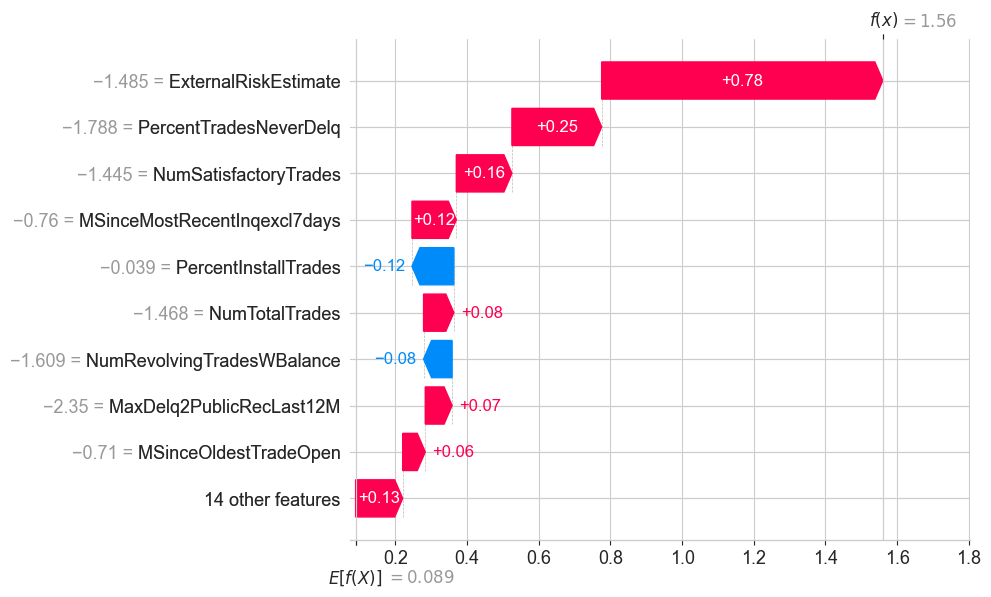

In [37]:
# Waterfall plot for a single prediction
sample_idx = correct_positive

print(f"\nWaterfall Plot for Index {sample_idx}")
print(f"True Label: {'Bad' if y_test[sample_idx] == 1 else 'Good'} ({y_test[sample_idx]})")
print(f"Predicted: {'Bad' if y_pred[sample_idx] == 1 else 'Good'} ({y_pred[sample_idx]})")
print(f"Probability: {y_prob[sample_idx]:.4f}")

shap.waterfall_plot(shap.Explanation(values=shap_values[sample_idx], 
                                     base_values=explainer.expected_value,
                                     data=X_test_scaled[sample_idx],
                                     feature_names=variable_names))

### 9.6 SHAP Decision Plot

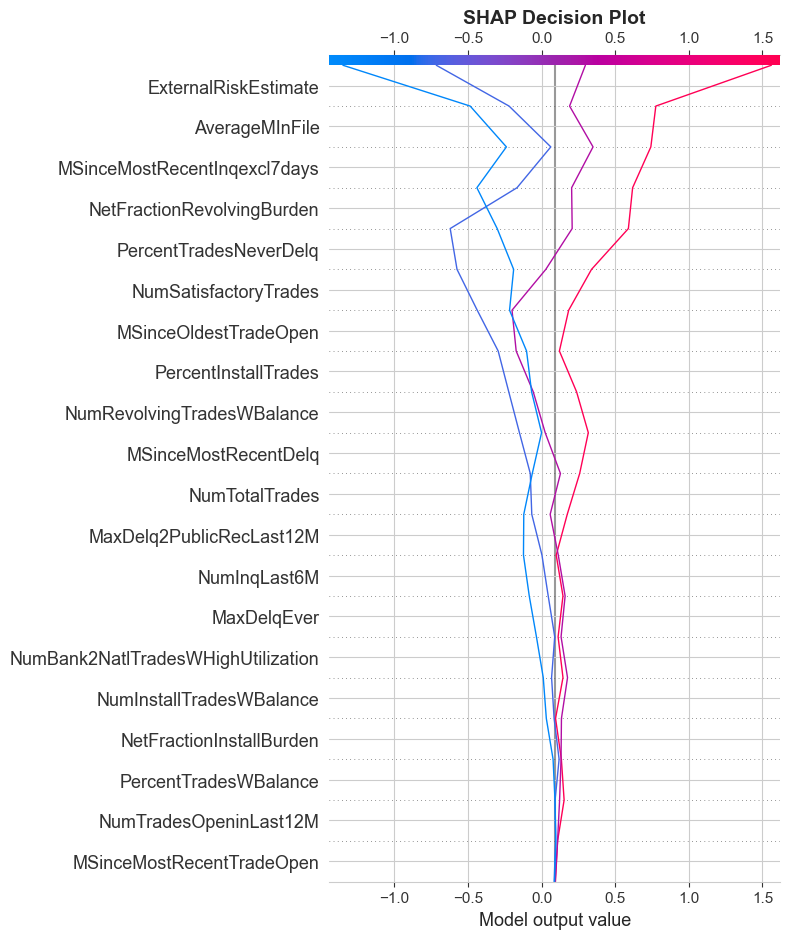

In [38]:
# Decision plot for multiple predictions
sample_indices = [correct_positive, correct_negative]
if false_positive is not None:
    sample_indices.append(false_positive)
if false_negative is not None:
    sample_indices.append(false_negative)

plt.figure(figsize=(10, 8))
shap.decision_plot(explainer.expected_value, 
                   shap_values[sample_indices], 
                   X_test_scaled[sample_indices],
                   feature_names=variable_names,
                   show=False)
plt.title('SHAP Decision Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary and Insights

In [39]:
print("\n" + "="*80)
print("SUMMARY OF RESULTS")
print("="*80)

print("\n1. MODEL CONFIGURATION:")
print(f"   - Algorithm: XGBoost Classifier")
print(f"   - Binning Strategy: {binning_strategy}")
print(f"   - Number of Bins: {n_bins}")
print(f"   - Continuous Features Binned: {len(continuous_features)}")
print(f"   - Cross-Validation Folds: {cv_folds}")

print("\n2. BEST HYPERPARAMETERS:")
for param, value in grid_search.best_params_.items():
    print(f"   - {param}: {value}")

print("\n3. CROSS-VALIDATION PERFORMANCE:")
print(f"   - Mean ROC AUC: {np.mean(fold_scores):.4f}")
print(f"   - Std Deviation: {np.std(fold_scores):.4f}")
print(f"   - Variance: {np.var(fold_scores):.6f}")
print(f"   - Coefficient of Variation: {(np.std(fold_scores) / np.mean(fold_scores)) * 100:.2f}%")

print("\n4. TEST SET PERFORMANCE:")
print(f"   - Accuracy: {test_accuracy:.4f}")
print(f"   - ROC AUC: {test_roc_auc:.4f}")

print("\n5. TOP 5 MOST IMPORTANT FEATURES (XGBoost):")
for i, row in feature_importance_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n6. TOP 5 MOST IMPORTANT FEATURES (SHAP):")
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': variable_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False)

for i, row in shap_importance_df.head(5).iterrows():
    print(f"   {list(shap_importance_df.index).index(i)+1}. {row['Feature']}: {row['Mean_Abs_SHAP']:.4f}")

print("\n7. MODEL STABILITY:")
if np.std(fold_scores) < 0.01:
    stability = "Excellent"
elif np.std(fold_scores) < 0.02:
    stability = "Good"
elif np.std(fold_scores) < 0.03:
    stability = "Fair"
else:
    stability = "Poor"
print(f"   - Stability Rating: {stability}")
print(f"   - Interpretation: The model shows {stability.lower()} consistency across folds")

print("\n" + "="*80)


SUMMARY OF RESULTS

1. MODEL CONFIGURATION:
   - Algorithm: XGBoost Classifier
   - Binning Strategy: quantile
   - Number of Bins: 5
   - Continuous Features Binned: 18
   - Cross-Validation Folds: 5

2. BEST HYPERPARAMETERS:
   - colsample_bytree: 0.8
   - gamma: 0
   - learning_rate: 0.1
   - max_depth: 3
   - min_child_weight: 1
   - n_estimators: 100
   - scale_pos_weight: 1
   - subsample: 1.0

3. CROSS-VALIDATION PERFORMANCE:
   - Mean ROC AUC: 0.7881
   - Std Deviation: 0.0106
   - Variance: 0.000112
   - Coefficient of Variation: 1.34%

4. TEST SET PERFORMANCE:
   - Accuracy: 0.7161
   - ROC AUC: 0.7827

5. TOP 5 MOST IMPORTANT FEATURES (XGBoost):
   1. ExternalRiskEstimate: 0.3782
   8. PercentTradesNeverDelq: 0.0981
   18. NetFractionRevolvingBurden: 0.0913
   15. MSinceMostRecentInqexcl7days: 0.0597
   4. AverageMInFile: 0.0517

6. TOP 5 MOST IMPORTANT FEATURES (SHAP):
   1. ExternalRiskEstimate: 0.5494
   2. MSinceMostRecentInqexcl7days: 0.2219
   3. NetFractionRevolvingB

## 11. Save Results

In [40]:
# Save the best model
import pickle

model_filename = 'xgboost_best_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Best model saved to {model_filename}")

# Save feature importance
feature_importance_df.to_csv('feature_importance_xgboost.csv', index=False)
print("Feature importance saved to feature_importance_xgboost.csv")

# Save SHAP importance
shap_importance_df.to_csv('feature_importance_shap.csv', index=False)
print("SHAP importance saved to feature_importance_shap.csv")

# Save CV results
cv_results_summary = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(cv_folds)],
    'ROC_AUC': fold_scores
})
cv_results_summary.to_csv('cv_results.csv', index=False)
print("CV results saved to cv_results.csv")

print("\nAll results saved successfully!")

Best model saved to xgboost_best_model.pkl
Feature importance saved to feature_importance_xgboost.csv
SHAP importance saved to feature_importance_shap.csv
CV results saved to cv_results.csv

All results saved successfully!
